In [ ]:
 !pip install category-encoders
 !pip install torch_geometric

In [ ]:
# Import packages
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score


In [ ]:
# Mount drive
# drive.mount("/content/drive")


from google.colab import files

uploaded = files.upload()

Saving product_category_name_translation.csv to product_category_name_translation (1).csv
Saving olist_sellers_dataset.csv to olist_sellers_dataset (1).csv
Saving olist_products_dataset.csv to olist_products_dataset (1).csv
Saving olist_orders_dataset.csv to olist_orders_dataset (1).csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset (1).csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset (1).csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset (1).csv
Saving olist_geolocation_dataset.csv to olist_geolocation_dataset (1).csv
Saving olist_customers_dataset.csv to olist_customers_dataset (1).csv


# **Data Preprocessing**

## Read Data

In [ ]:
# Read data
# folder_path = "/content/drive/MyDrive/2026 Spring - CSE6242/data/Brazil E-Commerce/"

# Load the datasets
# customers_df = pd.read_csv(folder_path + 'olist_customers_dataset.csv', dtype={"customer_zip_code_prefix": str})
# geolocation_df = pd.read_csv(folder_path +'olist_geolocation_dataset.csv', dtype={"geolocation_zip_code_prefix": str})
# order_items_df = pd.read_csv(folder_path +'olist_order_items_dataset.csv')
# order_payments_df = pd.read_csv(folder_path +'olist_order_payments_dataset.csv')
# order_reviews_df = pd.read_csv(folder_path +'olist_order_reviews_dataset.csv')
# orders_df = pd.read_csv(folder_path +'olist_orders_dataset.csv')
# products_df = pd.read_csv(folder_path +'olist_products_dataset.csv')
# sellers_df = pd.read_csv(folder_path +'olist_sellers_dataset.csv', dtype={"seller_zip_code_prefix": str})

In [ ]:
import pandas as pd

customers_df = pd.read_csv("olist_customers_dataset.csv", dtype={"customer_zip_code_prefix": str})
geolocation_df = pd.read_csv("olist_geolocation_dataset.csv", dtype={"geolocation_zip_code_prefix": str})
order_items_df = pd.read_csv("olist_order_items_dataset.csv")
order_payments_df = pd.read_csv("olist_order_payments_dataset.csv")
order_reviews_df = pd.read_csv("olist_order_reviews_dataset.csv")
orders_df = pd.read_csv("olist_orders_dataset.csv")
products_df = pd.read_csv("olist_products_dataset.csv")
sellers_df = pd.read_csv("olist_sellers_dataset.csv", dtype={"seller_zip_code_prefix": str})

print("✅ Loaded from upload (temporary)")

✅ Loaded from upload (temporary)


## Drop Duplicates

In [ ]:
# Drop duplicates
geolocation_df.drop_duplicates(subset=["geolocation_zip_code_prefix"], inplace=True)

## Infer Labels

In [ ]:
orders_df["order_delivered_customer_date"] = pd.to_datetime(orders_df["order_delivered_customer_date"]).dt.date
orders_df["order_estimated_delivery_date"] = pd.to_datetime(orders_df["order_estimated_delivery_date"]).dt.date
orders_df = orders_df[orders_df["order_status"] == "delivered"].copy() #only look at orders that been delivered
# Create a new column 'late_delivery' to indicate if the delivery was late
#late = different day (time is not relevant)
def late_delivery(row):
    if pd.isnull(row["order_delivered_customer_date"]) or pd.isnull(row["order_estimated_delivery_date"]):
        return 0  # return 0 if no date
    if row["order_delivered_customer_date"] > row["order_estimated_delivery_date"]:
        return 1
    else:
        return 0

orders_df["late_delivery"] = orders_df.apply(late_delivery, axis=1)
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10,2017-10-18,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07,2018-08-13,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17,2018-09-04,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02,2017-12-15,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16,2018-02-26,0


# **Feature Engineering**

## Merge Tables

In [ ]:
# Merge tables
df = orders_df[["order_id", "customer_id", "late_delivery"]].merge(order_items_df[["order_id", "product_id", "seller_id"]], how="left", on="order_id")
df = df.merge(products_df[["product_id", "product_category_name", "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]], how="left", on="product_id")
df = df.merge(sellers_df[["seller_id", "seller_zip_code_prefix", "seller_city", "seller_state"]], how="left", on="seller_id")
df = df.merge(customers_df[["customer_id", "customer_zip_code_prefix", "customer_city", "customer_state"]], how="left", on="customer_id")
df = df.merge(order_payments_df[["order_id", "payment_type"]], how="left", on="order_id")

In [ ]:
# Get the lat and long for the seller's location
df = df.merge(geolocation_df[["geolocation_zip_code_prefix", "geolocation_lat", "geolocation_lng"]], how="left", left_on="seller_zip_code_prefix", right_on="geolocation_zip_code_prefix")
df = df.drop(columns=["geolocation_zip_code_prefix"])
df = df.rename(columns={"geolocation_lat": "seller_lat", "geolocation_lng": "seller_lng"})

In [ ]:
# Get the lat and long for the customer's location
df = df.merge(geolocation_df[["geolocation_zip_code_prefix", "geolocation_lat", "geolocation_lng"]], how="left", left_on="customer_zip_code_prefix", right_on="geolocation_zip_code_prefix")
df = df.drop(columns=["geolocation_zip_code_prefix"])
df = df.rename(columns={"geolocation_lat": "customer_lat", "geolocation_lng": "customer_lng"})

In [ ]:
# Drop unnecessary columns & nans
data = df.drop(columns=["order_id", "customer_id", "product_id", "seller_zip_code_prefix", "customer_zip_code_prefix", "seller_state", "customer_state"])
data = data.dropna()
data.head()

,late_delivery,seller_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_city,customer_city,payment_type,seller_lat,seller_lng,customer_lat,customer_lng
0,0,3504c0cb71d7fa48d967e0e4c94d59d9,utilidades_domesticas,500.0,19.0,8.0,13.0,maua,sao paulo,credit_card,-23.680114,-46.452454,-23.574809,-46.587471
1,0,3504c0cb71d7fa48d967e0e4c94d59d9,utilidades_domesticas,500.0,19.0,8.0,13.0,maua,sao paulo,voucher,-23.680114,-46.452454,-23.574809,-46.587471
2,0,3504c0cb71d7fa48d967e0e4c94d59d9,utilidades_domesticas,500.0,19.0,8.0,13.0,maua,sao paulo,voucher,-23.680114,-46.452454,-23.574809,-46.587471
3,0,289cdb325fb7e7f891c38608bf9e0962,perfumaria,400.0,19.0,13.0,19.0,belo horizonte,barreiras,boleto,-19.810119,-43.984727,-12.169860,-44.988369
4,0,4869f7a5dfa277a7dca6462dcf3b52b2,automotivo,420.0,24.0,19.0,21.0,guariba,vianopolis,credit_card,-21.362358,-48.232976,-16.746337,-48.514624


In [ ]:
count1 = orders_df["late_delivery"].value_counts().rename({0: "On Time", 1: "Late"})
prop = orders_df["late_delivery"].value_counts(normalize=True).rename({0: "On Time", 1: "Late"}) * 100
display(count1, prop)

,count
late_delivery,
On Time,89944
Late,6534


,proportion
late_delivery,
On Time,93.227472
Late,6.772528


## Split Data

In [ ]:
X = data.drop(columns=["late_delivery"])
y = data["late_delivery"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Feature Encoding

In [ ]:
# One-hot encode categorical features: payment_type
categorical_features = ["payment_type"]
X_train = pd.get_dummies(X_train, columns=categorical_features)
X_test = pd.get_dummies(X_test, columns=categorical_features)

#align columns after get_dummies
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [ ]:
# Target encoding for seller_city, customer_city, and seller_id
features = ['seller_id', 'seller_city', 'customer_city', 'product_category_name']
encoder = TargetEncoder(cols=features, smoothing=10)
X_train[features] = encoder.fit_transform(X_train[features], y_train)
X_test[features] = encoder.transform(X_test[features])

X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [ ]:
# Calculate the distance between the seller and the customer using the Haversine formula
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)

    a = np.sin(delta_phi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

X_train["distance"] = haversine(X_train["seller_lat"], X_train["seller_lng"], X_train["customer_lat"], X_train["customer_lng"])
X_test["distance"] = haversine(X_test["seller_lat"], X_test["seller_lng"], X_test["customer_lat"], X_test["customer_lng"])

In [ ]:
# Standardize the numerical features: product_weight_g, product_length_cm, product_height_cm, product_width_cm, and distance
numerical_features = ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm", "distance"]

scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

In [ ]:
# Normalize the lat and long features: seller_lat, seller_lng, customer_lat, customer_lng
min_max_scaler = MinMaxScaler()

coordinate_cols = ["seller_lat", "seller_lng", "customer_lat", "customer_lng"]
X_train[coordinate_cols] = min_max_scaler.fit_transform(X_train[coordinate_cols])
X_test[coordinate_cols] = min_max_scaler.transform(X_test[coordinate_cols])

In [ ]:
X_train.head()

,seller_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_city,customer_city,seller_lat,seller_lng,customer_lat,customer_lng,payment_type_boleto,payment_type_credit_card,payment_type_debit_card,payment_type_voucher,distance
13207,0.043269,0.048780,-0.521760,-0.636840,-0.271000,-0.693380,0.057915,0.034242,0.369314,0.604553,0.188336,0.371908,1.0,0.0,0.0,0.0,-0.422822
5718,0.059243,0.064740,-0.215431,-0.885094,-0.047748,1.443268,0.059243,0.039216,0.487996,0.675513,0.167829,0.323167,0.0,1.0,0.0,0.0,0.458574
94432,0.069107,0.051020,-0.228749,-0.140332,0.324338,0.503143,0.069107,0.101087,0.499517,0.692634,0.180815,0.394546,0.0,1.0,0.0,0.0,-0.206794
20699,0.112142,0.076501,-0.361936,-0.512713,-0.345418,-0.095119,0.064768,0.057971,0.382299,0.603820,0.164185,0.408575,0.0,1.0,0.0,0.0,-0.994966
22053,0.065728,0.064740,-0.341958,-0.760967,0.696425,-0.095119,0.065728,0.165124,0.453235,0.560355,0.120562,0.312925,0.0,1.0,0.0,0.0,0.381765


# **XGBoost**

In [ ]:
import xgboost as xgb

# Calculate the ratio
counts = y_train.value_counts()
ratio = counts[0] / counts[1]

# Initialize model with the weight
model = xgb.XGBClassifier(
    scale_pos_weight=ratio,
    use_label_encoder=False,
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:54:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# calculate area under roc
y_rf_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_rf_prob)
print(f"XGBoost AUC: {auc:.4f}")

              precision    recall  f1-score   support

           0       0.96      0.80      0.87     21100
           1       0.16      0.53      0.24      1472

    accuracy                           0.78     22572
   macro avg       0.56      0.66      0.56     22572
weighted avg       0.91      0.78      0.83     22572

[[16859  4241]
 [  693   779]]
XGBoost AUC: 0.7096


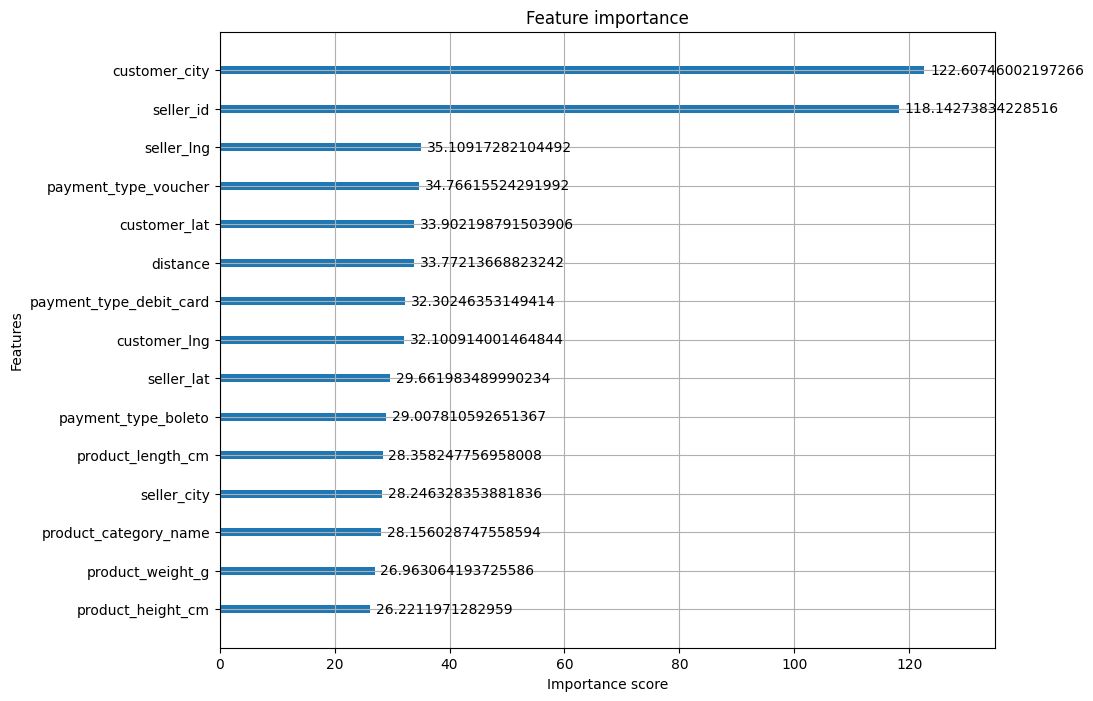

In [ ]:
# Feature importance
xgb.plot_importance(model, max_num_features=15, importance_type='gain')
plt.rcParams["figure.figsize"] = (10, 8)
plt.show()

# **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced_subsample')
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', random_state=42)

In [ ]:
# Evaluation
y_rf_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_rf_pred))
print(confusion_matrix(y_test, y_rf_pred))

# calculate area under roc
y_rf_prob = rf_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_rf_prob)
print(f"Random Forest AUC: {auc:.4f}")

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     21100
           1       0.70      0.17      0.27      1472

    accuracy                           0.94     22572
   macro avg       0.82      0.58      0.62     22572
weighted avg       0.93      0.94      0.92     22572

[[20993   107]
 [ 1223   249]]
Random Forest AUC: 0.7396


In [ ]:
# calculate feature importance for random forest
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)
feature_importance_df

,Feature,Importance
7,customer_city,0.163634
0,seller_id,0.144971
11,customer_lng,0.106855
10,customer_lat,0.098342
16,distance,0.094886
2,product_weight_g,0.063974
4,product_height_cm,0.046912
6,seller_city,0.044453
3,product_length_cm,0.044431
9,seller_lng,0.043591


# **GAT**

In [ ]:
# Reset indices of the training and testing sets
X_train.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)

X_test.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

In [ ]:
import os
import random
import numpy as np
import torch

SEED = 42

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # For reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

In [ ]:
from sklearn.neighbors import NearestNeighbors
import torch

# Build edge index
def build_sparse_shipping_edges(df, k=5):
    edge_indices = []
    groups = df.groupby(["customer_city"])

    for _, group in groups:
        indices = group.index.values
        if len(indices) <= 1:
            continue

        # Use coordinates to find the most relevant neighbors within the group
        coords = group[["customer_lat", "customer_lng"]].values
        n_neighbors = min(k + 1, len(indices))

        nn = NearestNeighbors(n_neighbors=n_neighbors)
        nn.fit(coords)
        _, nn_indices = nn.kneighbors(coords)

        for i in range(len(indices)):
            for neighbor_idx in nn_indices[i][1:]:  # skip self
                edge_indices.append([indices[i], indices[neighbor_idx]])

    if len(edge_indices) == 0:
        return torch.empty((2, 0), dtype=torch.long)

    return torch.tensor(edge_indices, dtype=torch.long).t().contiguous()

train_edge_index = build_sparse_shipping_edges(X_train)
test_edge_index = build_sparse_shipping_edges(X_test)

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv
from torch.nn import Linear, BatchNorm1d, Sequential, ReLU

class SupplyChainGAT(torch.nn.Module):
    def __init__(self, num_node_features, hidden_dim=32, heads=8):
        super(SupplyChainGAT, self).__init__()

        self.conv1 = GATv2Conv(
            num_node_features,
            hidden_dim,
            heads=heads,
            dropout=0.3
        )
        self.bn1 = BatchNorm1d(hidden_dim * heads)

        # Residual connection
        self.residual = Linear(num_node_features, hidden_dim * heads)

        # Final classifier
        self.classifier = Sequential(
            Linear(hidden_dim * heads + num_node_features, 64),
            ReLU(),
            BatchNorm1d(64),
            Linear(64, 1)
        )

    def forward(self, data):
        x_orig, edge_index = data.x, data.edge_index

        # Graph attention layer
        x_graph = self.conv1(x_orig, edge_index)
        x_graph = self.bn1(x_graph)

        # Residual connection
        x_res = self.residual(x_orig)
        x = F.elu(x_graph + x_res)

        x = F.dropout(x, p=0.3, training=self.training)

        # Concatenate graph embedding with original features
        combined = torch.cat([x, x_orig], dim=1)

        return self.classifier(combined)

In [ ]:
from torch_geometric.data import Data

# Boolean to float conversion for PyTorch
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Create PyTorch Geometric Data objects for training and testing
train_data = Data(
    x=torch.tensor(X_train.values, dtype=torch.float),
    edge_index=train_edge_index,
    y=torch.tensor(y_train.values, dtype=torch.float)
)

test_data = Data(
    x=torch.tensor(X_test.values, dtype=torch.float),
    edge_index=test_edge_index,
    y=torch.tensor(y_test.values, dtype=torch.float)
)

In [ ]:
# Set seed again before model creation for consistent initialization
set_seed(SEED)

# Calculate class weights
num_on_time = (y_train == 0).sum()
num_late = (y_train == 1).sum()
weight_for_late = num_on_time / num_late
weight_for_late = torch.tensor([weight_for_late], dtype=torch.float)

model = SupplyChainGAT(num_node_features=train_data.num_features)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=weight_for_late)

In [ ]:
def train():
    model.train()
    optimizer.zero_grad()

    # Forward pass
    out = model(train_data).squeeze()
    loss = criterion(out, train_data.y.float())

    # Backward pass
    loss.backward()
    optimizer.step()

    return loss.item()

for epoch in range(1, 50):
    loss = train()
    print(f"Epoch {epoch:03d}, Loss: {loss:.4f}")

Epoch 001, Loss: 1.3750
Epoch 002, Loss: 1.6593
Epoch 003, Loss: 1.4257
Epoch 004, Loss: 1.3332
Epoch 005, Loss: 1.3011
Epoch 006, Loss: 1.2875
Epoch 007, Loss: 1.2821
Epoch 008, Loss: 1.2828
Epoch 009, Loss: 1.2813
Epoch 010, Loss: 1.2755
Epoch 011, Loss: 1.2696
Epoch 012, Loss: 1.2651
Epoch 013, Loss: 1.2586
Epoch 014, Loss: 1.2549
Epoch 015, Loss: 1.2523
Epoch 016, Loss: 1.2520
Epoch 017, Loss: 1.2496
Epoch 018, Loss: 1.2477
Epoch 019, Loss: 1.2449
Epoch 020, Loss: 1.2404
Epoch 021, Loss: 1.2362
Epoch 022, Loss: 1.2301
Epoch 023, Loss: 1.2276
Epoch 024, Loss: 1.2223
Epoch 025, Loss: 1.2158
Epoch 026, Loss: 1.2083
Epoch 027, Loss: 1.2011
Epoch 028, Loss: 1.1924
Epoch 029, Loss: 1.1825
Epoch 030, Loss: 1.1718
Epoch 031, Loss: 1.1660
Epoch 032, Loss: 1.1532
Epoch 033, Loss: 1.1511
Epoch 034, Loss: 1.1425
Epoch 035, Loss: 1.1381
Epoch 036, Loss: 1.1342
Epoch 037, Loss: 1.1315
Epoch 038, Loss: 1.1282
Epoch 039, Loss: 1.1209
Epoch 040, Loss: 1.1237
Epoch 041, Loss: 1.1177
Epoch 042, Loss:

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

@torch.no_grad()
def test(data):
    model.eval()

    logits = model(data).squeeze()
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    print(classification_report(data.y.cpu(), preds.cpu()))

    y_scores = probs.cpu().numpy()
    auc = roc_auc_score(data.y.cpu().numpy(), y_scores)
    print(f"The AUC-ROC is: {auc}")

print("--- GAT Test Set Performance ---")
test(test_data)

--- GAT Test Set Performance ---
              precision    recall  f1-score   support

         0.0       0.96      0.75      0.84     21100
         1.0       0.13      0.51      0.20      1472

    accuracy                           0.74     22572
   macro avg       0.54      0.63      0.52     22572
weighted avg       0.90      0.74      0.80     22572

The AUC-ROC is: 0.6853196637389244


# Further Analysis


In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GCNConv, SAGEConv
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
import os
import random
import numpy as np
import torch

SEED = 42

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# MLP

In [ ]:
class SupplyChainMLP(nn.Module):
    def __init__(self, num_features, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_features, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class SupplyChainGCN(nn.Module):
    def __init__(self, num_node_features, hidden_dim=32):
        super().__init__()

        self.conv1 = GCNConv(num_node_features, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)

        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim + num_node_features, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, data):
        x_orig, edge_index = data.x, data.edge_index

        x = self.conv1(x_orig, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)

        x = torch.cat([x, x_orig], dim=1)
        return self.classifier(x)

In [ ]:
class SupplyChainSAGE(nn.Module):
    def __init__(self, num_node_features, hidden_dim=32):
        super().__init__()

        self.conv1 = SAGEConv(num_node_features, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)

        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim + num_node_features, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, data):
        x_orig, edge_index = data.x, data.edge_index

        x = self.conv1(x_orig, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)

        x = torch.cat([x, x_orig], dim=1)
        return self.classifier(x)

In [ ]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float)

In [ ]:
def train_graph_model(model, train_data, optimizer, criterion, epochs=50):
    model.train()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        out = model(train_data).squeeze()
        loss = criterion(out, train_data.y.float())
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch:03d}, Loss: {loss.item():.4f}")

In [ ]:
@torch.no_grad()
def evaluate_graph_model(model, data, y_true):
    model.eval()
    logits = model(data).squeeze()
    probs = torch.sigmoid(logits).cpu().numpy()
    preds = (probs > 0.5).astype(int)

    print(classification_report(y_true, preds))
    auc = roc_auc_score(y_true, probs)
    print(f"The AUC-ROC is: {auc}")

    return {
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
        "auc_roc": auc
    }

In [ ]:
def train_mlp_model(model, X_train_tensor, y_train_tensor, optimizer, criterion, epochs=50):
    model.train()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        out = model(X_train_tensor).squeeze()
        loss = criterion(out, y_train_tensor.float())
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch:03d}, Loss: {loss.item():.4f}")

In [ ]:
@torch.no_grad()
def evaluate_mlp_model(model, X_test_tensor, y_true):
    model.eval()
    logits = model(X_test_tensor).squeeze()
    probs = torch.sigmoid(logits).cpu().numpy()
    preds = (probs > 0.5).astype(int)

    print(classification_report(y_true, preds))
    auc = roc_auc_score(y_true, probs)
    print(f"The AUC-ROC is: {auc}")

    return {
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
        "auc_roc": auc
    }

In [ ]:
set_seed(SEED)

mlp_model = SupplyChainMLP(num_features=X_train.shape[1], hidden_dim=64)
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.005, weight_decay=5e-4)
mlp_criterion = torch.nn.BCEWithLogitsLoss(pos_weight=weight_for_late)

print("----- Training MLP -----")
train_mlp_model(
    mlp_model,
    X_train_tensor,
    y_train_tensor,
    mlp_optimizer,
    mlp_criterion,
    epochs=50
)

print("\n--- MLP Test Set Performance ---")
mlp_results = evaluate_mlp_model(mlp_model, X_test_tensor, y_test.values)

----- Training MLP -----
Epoch 001, Loss: 1.4276
Epoch 002, Loss: 1.3470
Epoch 003, Loss: 1.3344
Epoch 004, Loss: 1.3214
Epoch 005, Loss: 1.3118
Epoch 006, Loss: 1.3051
Epoch 007, Loss: 1.3013
Epoch 008, Loss: 1.2943
Epoch 009, Loss: 1.2945
Epoch 010, Loss: 1.2854
Epoch 011, Loss: 1.2862
Epoch 012, Loss: 1.2805
Epoch 013, Loss: 1.2829
Epoch 014, Loss: 1.2786
Epoch 015, Loss: 1.2754
Epoch 016, Loss: 1.2772
Epoch 017, Loss: 1.2749
Epoch 018, Loss: 1.2723
Epoch 019, Loss: 1.2684
Epoch 020, Loss: 1.2656
Epoch 021, Loss: 1.2631
Epoch 022, Loss: 1.2638
Epoch 023, Loss: 1.2596
Epoch 024, Loss: 1.2563
Epoch 025, Loss: 1.2532
Epoch 026, Loss: 1.2497
Epoch 027, Loss: 1.2464
Epoch 028, Loss: 1.2422
Epoch 029, Loss: 1.2374
Epoch 030, Loss: 1.2326
Epoch 031, Loss: 1.2265
Epoch 032, Loss: 1.2253
Epoch 033, Loss: 1.2184
Epoch 034, Loss: 1.2103
Epoch 035, Loss: 1.2098
Epoch 036, Loss: 1.1976
Epoch 037, Loss: 1.1904
Epoch 038, Loss: 1.1834
Epoch 039, Loss: 1.1784
Epoch 040, Loss: 1.1691
Epoch 041, Loss

# GNN

In [ ]:
set_seed(SEED)

sage_model = SupplyChainSAGE(num_node_features=train_data.num_features, hidden_dim=32)
sage_optimizer = torch.optim.Adam(sage_model.parameters(), lr=0.005, weight_decay=5e-4)
sage_criterion = torch.nn.BCEWithLogitsLoss(pos_weight=weight_for_late)

print("----- Training GNN -----")
train_graph_model(sage_model, train_data, sage_optimizer, sage_criterion, epochs=50)

print("\n--- GNN Test Set Performance ---")
sage_results = evaluate_graph_model(sage_model, test_data, y_test.values)

----- Training GNN -----
Epoch 001, Loss: 1.3824
Epoch 002, Loss: 1.3405
Epoch 003, Loss: 1.3201
Epoch 004, Loss: 1.3104
Epoch 005, Loss: 1.3047
Epoch 006, Loss: 1.3005
Epoch 007, Loss: 1.2918
Epoch 008, Loss: 1.2850
Epoch 009, Loss: 1.2834
Epoch 010, Loss: 1.2788
Epoch 011, Loss: 1.2743
Epoch 012, Loss: 1.2720
Epoch 013, Loss: 1.2692
Epoch 014, Loss: 1.2687
Epoch 015, Loss: 1.2656
Epoch 016, Loss: 1.2617
Epoch 017, Loss: 1.2606
Epoch 018, Loss: 1.2594
Epoch 019, Loss: 1.2560
Epoch 020, Loss: 1.2546
Epoch 021, Loss: 1.2551
Epoch 022, Loss: 1.2530
Epoch 023, Loss: 1.2517
Epoch 024, Loss: 1.2470
Epoch 025, Loss: 1.2461
Epoch 026, Loss: 1.2419
Epoch 027, Loss: 1.2358
Epoch 028, Loss: 1.2339
Epoch 029, Loss: 1.2315
Epoch 030, Loss: 1.2256
Epoch 031, Loss: 1.2184
Epoch 032, Loss: 1.2126
Epoch 033, Loss: 1.2048
Epoch 034, Loss: 1.1932
Epoch 035, Loss: 1.1932
Epoch 036, Loss: 1.1807
Epoch 037, Loss: 1.1740
Epoch 038, Loss: 1.1668
Epoch 039, Loss: 1.1570
Epoch 040, Loss: 1.1456
Epoch 041, Loss

# GCN

In [ ]:
set_seed(SEED)

gcn_model = SupplyChainGCN(num_node_features=train_data.num_features, hidden_dim=32)
gcn_optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.005, weight_decay=5e-4)
gcn_criterion = torch.nn.BCEWithLogitsLoss(pos_weight=weight_for_late)

print("----- Training GCN -----")
train_graph_model(gcn_model, train_data, gcn_optimizer, gcn_criterion, epochs=50)

print("\n--- GCN Test Set Performance ---")
gcn_results = evaluate_graph_model(gcn_model, test_data, y_test.values)

----- Training GCN -----
Epoch 001, Loss: 1.3896
Epoch 002, Loss: 1.3380
Epoch 003, Loss: 1.3159
Epoch 004, Loss: 1.3028
Epoch 005, Loss: 1.2980
Epoch 006, Loss: 1.2933
Epoch 007, Loss: 1.2891
Epoch 008, Loss: 1.2829
Epoch 009, Loss: 1.2744
Epoch 010, Loss: 1.2780
Epoch 011, Loss: 1.2683
Epoch 012, Loss: 1.2684
Epoch 013, Loss: 1.2674
Epoch 014, Loss: 1.2644
Epoch 015, Loss: 1.2621
Epoch 016, Loss: 1.2595
Epoch 017, Loss: 1.2603
Epoch 018, Loss: 1.2564
Epoch 019, Loss: 1.2560
Epoch 020, Loss: 1.2553
Epoch 021, Loss: 1.2547
Epoch 022, Loss: 1.2477
Epoch 023, Loss: 1.2471
Epoch 024, Loss: 1.2454
Epoch 025, Loss: 1.2440
Epoch 026, Loss: 1.2374
Epoch 027, Loss: 1.2389
Epoch 028, Loss: 1.2346
Epoch 029, Loss: 1.2318
Epoch 030, Loss: 1.2278
Epoch 031, Loss: 1.2258
Epoch 032, Loss: 1.2175
Epoch 033, Loss: 1.2160
Epoch 034, Loss: 1.2120
Epoch 035, Loss: 1.2054
Epoch 036, Loss: 1.1999
Epoch 037, Loss: 1.1963
Epoch 038, Loss: 1.1895
Epoch 039, Loss: 1.1765
Epoch 040, Loss: 1.1734
Epoch 041, Loss

In [ ]:
@torch.no_grad()
def test_with_metrics(model, data):
    model.eval()

    logits = model(data).squeeze()
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    print(classification_report(data.y.cpu(), preds.cpu()))

    y_scores = probs.cpu().numpy()
    y_true = data.y.cpu().numpy()

    auc = roc_auc_score(y_true, y_scores)
    print(f"The AUC-ROC is: {auc}")

    return {
        "accuracy": accuracy_score(y_true, preds.cpu().numpy()),
        "precision": precision_score(y_true, preds.cpu().numpy(), zero_division=0),
        "recall": recall_score(y_true, preds.cpu().numpy(), zero_division=0),
        "f1": f1_score(y_true, preds.cpu().numpy(), zero_division=0),
        "auc_roc": auc
    }

print("--- GAT Test Set Performance ---")
gat_results = test_with_metrics(model, test_data)

--- GAT Test Set Performance ---
              precision    recall  f1-score   support

         0.0       0.96      0.75      0.84     21100
         1.0       0.13      0.51      0.20      1472

    accuracy                           0.74     22572
   macro avg       0.54      0.63      0.52     22572
weighted avg       0.90      0.74      0.80     22572

The AUC-ROC is: 0.6853196637389244


In [ ]:
results_df = pd.DataFrame([
    {"Model": "MLP", **mlp_results},
    {"Model": "GCN", **gcn_results},
    {"Model": "GNN", **sage_results},
    {"Model": "GAT", **gat_results}
])

results_df

,Model,accuracy,precision,recall,f1,auc_roc
0,MLP,0.860624,0.166268,0.283288,0.209548,0.692707
1,GCN,0.859649,0.166929,0.288723,0.211548,0.685236
2,GNN,0.868067,0.173461,0.271739,0.211752,0.699315
3,GAT,0.736576,0.126420,0.514266,0.202949,0.685320


In [ ]:
# print(y_test.value_counts())
# print(y_test.value_counts(normalize=True))

Feature Importances

In [ ]:
feature_names = list(X_train.columns)

In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

def get_mlp_feature_importance(model, X_tensor, feature_names):
    model.eval()

    X = X_tensor.clone().detach().requires_grad_(True)
    logits = model(X).squeeze()

    # Use mean logit so gradients summarize overall feature influence
    score = logits.mean()
    score.backward()

    importance = X.grad.abs().mean(dim=0).detach().cpu().numpy()

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    }).sort_values("Importance", ascending=False)

    return importance_df

mlp_importance_df = get_mlp_feature_importance(mlp_model, X_test_tensor, feature_names)
mlp_importance_df

,Feature,Importance
0,seller_id,0.000322
7,customer_city,0.000271
1,product_category_name,0.000153
6,seller_city,0.000130
11,customer_lng,0.000085
10,customer_lat,0.000041
14,payment_type_debit_card,0.000021
12,payment_type_boleto,0.000011
9,seller_lng,0.000010
13,payment_type_credit_card,0.000010


In [ ]:
def get_graph_feature_importance(model, data, feature_names):
    model.eval()

    x = data.x.clone().detach().requires_grad_(True)

    temp_data = data.clone()
    temp_data.x = x

    logits = model(temp_data).squeeze()

    # Use mean logit for global feature importance
    score = logits.mean()
    score.backward()

    importance = x.grad.abs().mean(dim=0).detach().cpu().numpy()

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    }).sort_values("Importance", ascending=False)

    return importance_df

gcn_importance_df = get_graph_feature_importance(gcn_model, test_data, feature_names)
sage_importance_df = get_graph_feature_importance(sage_model, test_data, feature_names)
gat_importance_df = get_graph_feature_importance(model, test_data, feature_names)

In [ ]:
print("MLP Feature Importance")
display(mlp_importance_df.head(10))

print("GCN Feature Importance")
display(gcn_importance_df.head(10))

print("GNN Feature Importance")
display(sage_importance_df.head(10))

print("GAT Feature Importance")
display(gat_importance_df.head(10))

MLP Feature Importance


,Feature,Importance
0,seller_id,0.000322
7,customer_city,0.000271
1,product_category_name,0.000153
6,seller_city,0.000130
11,customer_lng,0.000085
10,customer_lat,0.000041
14,payment_type_debit_card,0.000021
12,payment_type_boleto,0.000011
9,seller_lng,0.000010
13,payment_type_credit_card,0.000010


GCN Feature Importance


,Feature,Importance
0,seller_id,0.000329
7,customer_city,0.000328
6,seller_city,0.000198
11,customer_lng,0.000109
1,product_category_name,0.000096
10,customer_lat,0.000064
8,seller_lat,0.000040
12,payment_type_boleto,0.000013
15,payment_type_voucher,0.000011
9,seller_lng,0.000011


GNN Feature Importance


,Feature,Importance
7,customer_city,0.000407
0,seller_id,0.000380
6,seller_city,0.000241
1,product_category_name,0.000148
11,customer_lng,0.000090
10,customer_lat,0.000059
15,payment_type_voucher,0.000034
14,payment_type_debit_card,0.000031
13,payment_type_credit_card,0.000019
8,seller_lat,0.000018


GAT Feature Importance


,Feature,Importance
7,customer_city,0.000536
0,seller_id,0.000523
6,seller_city,0.000235
1,product_category_name,0.000127
11,customer_lng,0.000052
10,customer_lat,0.000039
8,seller_lat,0.000034
14,payment_type_debit_card,0.000022
9,seller_lng,0.000021
15,payment_type_voucher,0.000014


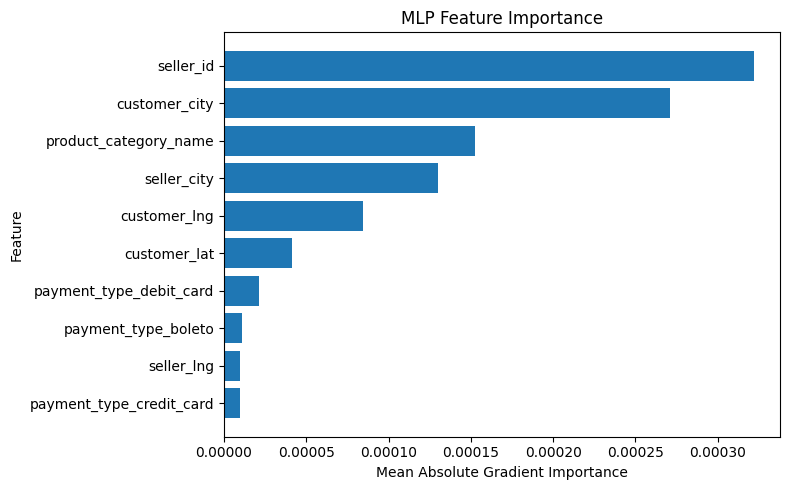

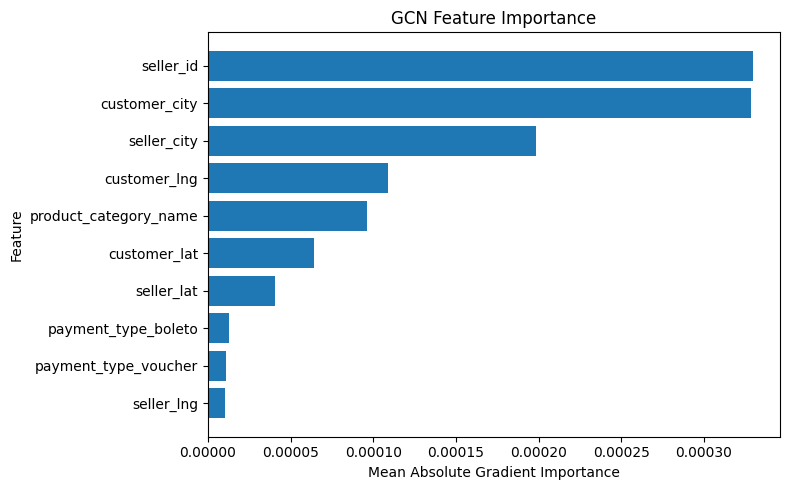

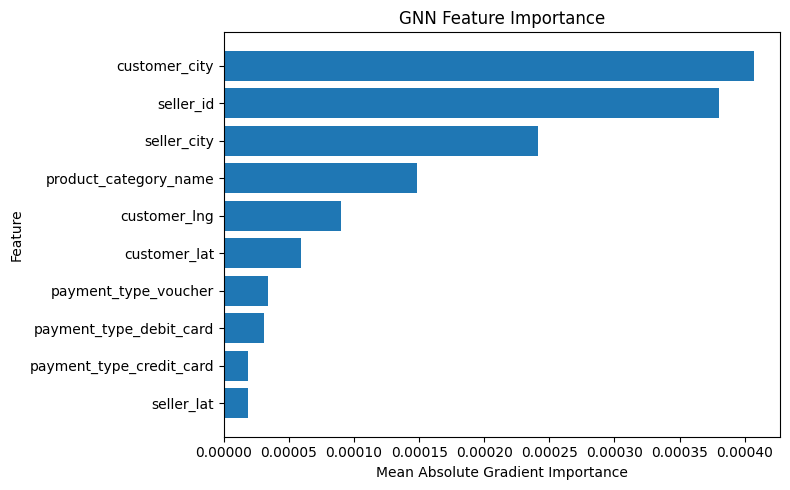

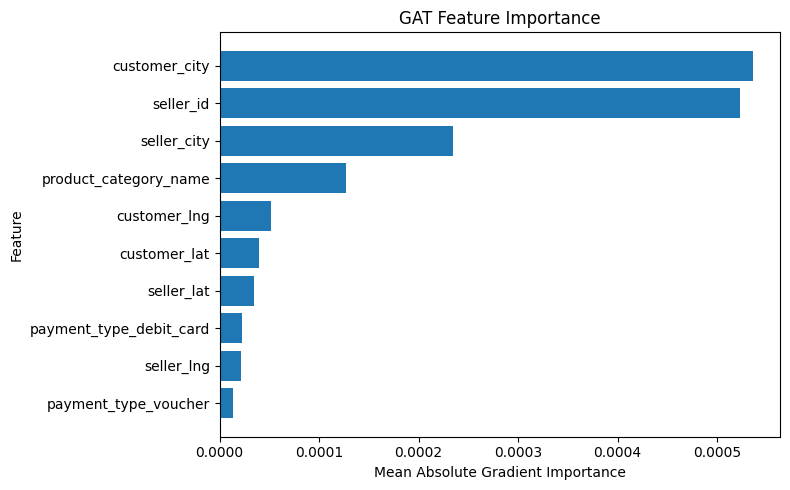

In [ ]:
def plot_feature_importance(importance_df, title, top_n=10):
    top_df = importance_df.head(top_n).iloc[::-1]

    plt.figure(figsize=(8, 5))
    plt.barh(top_df["Feature"], top_df["Importance"])
    plt.title(title)
    plt.xlabel("Mean Absolute Gradient Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

plot_feature_importance(mlp_importance_df, "MLP Feature Importance")
plot_feature_importance(gcn_importance_df, "GCN Feature Importance")
plot_feature_importance(sage_importance_df, "GNN Feature Importance")
plot_feature_importance(gat_importance_df, "GAT Feature Importance")

In [ ]:
combined_importance = pd.DataFrame({
    "Feature": feature_names,
    "MLP": mlp_importance_df.set_index("Feature").loc[feature_names]["Importance"].values,
    "GCN": gcn_importance_df.set_index("Feature").loc[feature_names]["Importance"].values,
    "GNN": sage_importance_df.set_index("Feature").loc[feature_names]["Importance"].values,
    "GAT": gat_importance_df.set_index("Feature").loc[feature_names]["Importance"].values
})

combined_importance

,Feature,MLP,GCN,GNN,GAT
0,seller_id,0.000322,0.000329,0.000380,0.000523
1,product_category_name,0.000153,0.000096,0.000148,0.000127
2,product_weight_g,0.000009,0.000007,0.000008,0.000003
3,product_length_cm,0.000004,0.000006,0.000005,0.000003
4,product_height_cm,0.000004,0.000005,0.000009,0.000007
5,product_width_cm,0.000005,0.000005,0.000005,0.000003
6,seller_city,0.000130,0.000198,0.000241,0.000235
7,customer_city,0.000271,0.000328,0.000407,0.000536
8,seller_lat,0.000009,0.000040,0.000018,0.000034
9,seller_lng,0.000010,0.000011,0.000010,0.000021
